# Hands-On Session 2: Building out your first RAG
## Topics:
1. Understanding the data
2. Experiment with different chunking strategies
3. Creating our vector database
4. Create a dataset that we can use to measure our model performance.

In [3]:
#@title #Installs, Imports and Global Variables
%%capture
%pip install ipython-autotime
%load_ext autotime
%pip install litellm pypdf PyMuPDF llama-index gradio ipywidgets ragas chromadb
%pip install llama-index-vector-stores-chroma llama-index-embeddings-litellm llama-index-llms-litellm
%pip install openinference-instrumentation-litellm litellm
%pip install arize-phoenix

time: 1min 42s (started: 2025-11-24 19:02:48 +00:00)


In [4]:
#@title Imports
import os
import random
import fitz  # PyMuPDF
import io
import pickle
import json
import openai
import gdown
import zipfile
import concurrent.futures

import numpy as np
import gradio as gr
import pandas as pd

from PIL import Image
from litellm import completion
from litellm import model_cost
from collections import defaultdict
from llama_index.core import SimpleDirectoryReader
from llama_index.core.ingestion import IngestionPipeline
from llama_index.core.node_parser import SentenceSplitter

from datasets import Dataset

from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
)

import litellm

litellm.drop_params = True

time: 51.9 s (started: 2025-11-24 19:04:31 +00:00)


In [ ]:
# Workshop API keys. Paste the keys handed out in the room; do not commit them.
# Phase 8 replaces this cell with a call to the hub's /api/env endpoint.
os.environ["OPENAI_API_KEY"] = ""

MODEL = 'gpt-4.1-nano'

TDS_FOLDER_PATH = "/content/downloaded_pdfs/"

# Download text splitting app file from github
!wget https://github.com/ndecavel/tdwi-workshop-labs/raw/main/Labs/Text_Splitting_App.py

### Download TDS documents from github
!wget https://github.com/ndecavel/tdwi-workshop-labs/raw/main/data/Data_Resources_TDS.zip

# !unzip /content/Data_Resources_TDS.zip
with zipfile.ZipFile('/content/Data_Resources_TDS.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [6]:
#@title Extract relevant available models given a few constraints

def filter_models_by_cost_and_provider(acceptable_providers: list, mode: str, max_input_cost_per_token_million: float, max_output_cost_per_token_million: float, structured_responses: bool) -> dict:
    """
    Filters models from the global model_cost dictionary based on acceptable providers and max token costs.

    Args:
        acceptable_providers: A list of strings representing the acceptable providers.
        mode: The mode of the model. (chat, embedding, etc. Based on LiteLLM)
        max_input_cost_per_token_million: The maximum acceptable input cost per token (in dollars per million tokens).
        max_output_cost_per_token_million: The maximum acceptable output cost per token (in dollars per million tokens).
        structured_responses: A boolean indicating whether we want the model to support structured responses

    Returns:
        A dictionary where keys are provider names and values are lists of model information
        dictionaries that meet the specified criteria, including their blended token cost.
    """
    filtered_models = defaultdict(list)
    for model_name, model_info in model_cost.items():
        provider = model_info.get('litellm_provider')
        input_cost_per_token = model_info.get('input_cost_per_token', 0)
        output_cost_per_token = model_info.get('output_cost_per_token', 0)
        model_mode = model_info.get('mode')
        supports_response_schema = model_info.get('supports_response_schema', False)
        supported_output_modalities = model_info.get('supported_output_modalities', [])

        if structured_responses and not supports_response_schema:
            continue

        # Convert cost per token to cost per million tokens for comparison
        input_cost_per_token_million = round(input_cost_per_token * 1_000_000, 4)
        output_cost_per_token_million = round(output_cost_per_token * 1_000_000, 4)

        # Calculate blended cost (simple average for now)
        blended_cost_per_token_million = round((input_cost_per_token_million + output_cost_per_token_million) / 2, 4)
        if blended_cost_per_token_million == 0 or model_mode != mode:
            continue
        if provider in acceptable_providers and \
            input_cost_per_token_million <= max_input_cost_per_token_million and \
            output_cost_per_token_million <= max_output_cost_per_token_million:
            # Include all model_info and the blended cost
            model_info_with_cost = model_info.copy()
            model_info_with_cost['blended_cost_per_token_million'] = blended_cost_per_token_million
            # Additional filtering for openai models based on supported_output_modalities
            if provider == 'openai':
                if 'text' not in supported_output_modalities and mode == 'chat':
                  continue
            if provider == 'gemini':
              ### Skipping the below two models due to issues
              if model_name in ["gemini/gemini-1.5-flash-001", "gemini/gemini-2.0-flash-preview-image-generation"]:
                continue
              ### Small filter on requests per minute just to reduce returned list a bit.
              if model_info['rpm'] < 100 and mode == 'chat':
                continue
            filtered_models[provider].append({model_name: model_info_with_cost})


    return filtered_models

available_models = filter_models_by_cost_and_provider(acceptable_providers=['openai', 'gemini'],
                                                      mode='chat',
                                                      max_input_cost_per_token_million=3,
                                                      max_output_cost_per_token_million=3,
                                                      structured_responses=True)

available_embedding_models = filter_models_by_cost_and_provider(acceptable_providers=['openai', 'gemini'],
                                                      mode='embedding',
                                                      max_input_cost_per_token_million=3,
                                                      max_output_cost_per_token_million=3,
                                                      structured_responses=False)

time: 34.8 ms (started: 2025-11-24 19:05:27 +00:00)


____
## 1. Understanding the data
For this hands-on session, we will be focusing on using product data sheets of products for BEHR paint. Our focus is to help create a natural-language Question-Ansering interface that will allow us to query and cite our information appropriately without the need to search for the right document.

With any problem, it is critical for us to view the data being inputted in the model to better understand.

In [7]:
from IPython.display import display, clear_output
from ipywidgets import Button, Output, VBox, Layout
import fitz
from PIL import Image
import io
import random
import os

def get_random_pdf_image():
    """Opens a random PDF from the TDS_FOLDER_PATH and returns the first page as a PIL Image."""
    pdf_files = [f for f in os.listdir(TDS_FOLDER_PATH) if f.endswith('.pdf')]
    if not pdf_files:
        return None

    sample_pdf = os.path.join(TDS_FOLDER_PATH, random.choice(pdf_files))
    pdf_document = fitz.open(sample_pdf)
    page = pdf_document.load_page(0)
    pix = page.get_pixmap()
    img = Image.open(io.BytesIO(pix.tobytes()))
    pdf_document.close()
    return img

# Create output area
output = Output()

# Create button with larger size
button = Button(
    description="Click to Show New PDF",
    layout=Layout(
        width='250px',      # Button width
        height='70px'       # Button height
    ),
    style={
        'button_color': 'yellow',   # Yellow color
        'font_weight': 'bold',   # Bold text
    }
)

def show_random_pdf():
    """Display a random PDF image"""
    with output:
        clear_output(wait=True)
        img = get_random_pdf_image()
        if img:
            display(img)
        else:
            print("No PDF found")

# Set up button click handler
button.on_click(lambda b: show_random_pdf())

# Show initial PDF on first run
show_random_pdf()

# Display the button and output area
display(VBox([button, output]))

time: 654 ms (started: 2025-11-24 19:05:27 +00:00)


The above PDF is an example of 1 of 137 BEHR Technical Data Sheets (TDS). As we can see, it includes information such as
Product Information, Recommended Uses, Product Specifications, etc.


I want to note that, visually, this TDS layout is very clear to a human reader. It has distinct subsections and tables with information that allows us to quickly pinpoint where in the document we need to look to answer any questions we may have about the product. That being said, we will learn that translating this information to be easy and accessible for our RAG solution is more complex. We will go over specific solutions to this in our next lab. For now, we can focus on using simpler chunking/embedding methogologies to set up our baseline.

____
## Brief aside: Business Relevance

When integrating data into your RAG solution, ensure it's tied to your business problem. For BEHR, TDS sheets are crucial as they cover various scenarios, such as:
- **Product Usage Questions:** "What are the recommended uses for a particular stain?"
- **Application Guidance:** "What tools do I need?"
- **Safety Precautions:** "What should I do if the stain is ingested?"

By incorporating these documents, we can enhance customer support and provide quick and accurate information.

**I challenge anyone building out a RAG solution to have a clear idea of the questions that solution is hoping to answer. This exercise will allow you to not only filter the necessary data to use in the solution, but to help justify where the solution is delivering value to the business.**


...

Okay, now back to building out first RAG pipeline!
_____

To start, we will experiment with a few simple chunking strategies to help create our first vector store! The following code will allow you to interactively parse and chunk from our documents using different text parsers. You can adjust the parameters for `TokenTextSplitter` and `SentenceSplitter` to see how they affect the chunking of the text. The extracted text chunks will be displayed below.

## Instructions:
1. Run the following code and select the link that appears in the output (or run the interface within the code)
2. Experiment with different chunking stragies and compare their results.

🤔 Do you notice any issues with the documents and the chunks being displayed? If you were assigned a task that relied on this data, but were provided only the chunk of text information and not the pdf itself, would you be able to make sense of it?
---

* * *
### Run the cell below to launch the chunking comparison app inside your own Colab session.
It lets you explore both sentence splitting and token text splitting on our current data. Each attendee runs a private copy, so it does not slow down when the whole room uses it.


In [ ]:
#@title Launch the chunking comparison app (runs locally in this Colab session)
from Text_Splitting_App import launch_app

launch_app(TDS_FOLDER_PATH)


____

As we can see, the chunks created from the technical data sheets do not seem to accurately represent the information being displayed. To start, we will use the SentenceSplitter as our more naive approach in order to measure the improvements of more advanced techniques in the next hands-on session.


The following code will go through each of our TDS pdfs and chunk their information into a vector database. In this example, we will use simply use llama index with an ephemeral chromadb. Note: There are many ways to store the data, and it is important to understand the pros/cons of each when deciding which to use in production. In particular, if your system uses postgres, you may be better suited sticking to using pgvector versus having to maintain a new database altogether. We will also use llama_index ingestion pipelines to run a job that embeds each chunk into our dataframe.
In addition, we will use the text-embedding-3-small embedding model (https://platform.openai.com/docs/guides/embeddings).

In [8]:
from llama_index.core import VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from IPython.display import Markdown, display
from llama_index.embeddings.litellm import LiteLLMEmbedding

import chromadb

time: 1.02 s (started: 2025-11-24 19:05:27 +00:00)


In [9]:
#@title Data ingestion pipeline (~1-3 min)

## Step 0. Initialize chromadb
chroma_client = chromadb.EphemeralClient()
chroma_collection = chroma_client.get_or_create_collection(
                    name="initial_collection",
                    configuration={"hnsw": {"space": "cosine"}}
                )
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

## Step 1. Use llama-index to create a DirectoryReader
documents = SimpleDirectoryReader(TDS_FOLDER_PATH).load_data(num_workers=-2)


## Step 2. Run through a simple IngestionPipeline, gather our embeddings and add them to our vector store

pipeline = IngestionPipeline(
    transformations=[SentenceSplitter(chunk_size=256, chunk_overlap=32),
                     LiteLLMEmbedding(model_name='text-embedding-3-small')
                     ],
    vector_store=vector_store)
# pipeline = IngestionPipeline(
#     transformations=[TokenSplitter(chunk_size=512, chunk_overlap=128),
#                      LiteLLMEmbedding(model_name='text-embedding-3-small')
#                      ],
#     vector_store=vector_store)

nodes = pipeline.run(documents=documents, num_workers=-2)

time: 3min 1s (started: 2025-11-24 19:05:28 +00:00)


In [10]:
index = VectorStoreIndex.from_vector_store(vector_store)

time: 448 ms (started: 2025-11-24 19:08:30 +00:00)


In [11]:
from llama_index.core.prompts import RichPromptTemplate

retriever = index.as_retriever(similarity_top_k=5)

template_str = """We have provided context information below.
---------------------
{{ context_str }}
---------------------
Given this information, please answer the question: {{ query_str }}
"""

qa_template = RichPromptTemplate(template_str)

query_str = "what should I use to paint my garage floor?" #@param {"type": "string"}

nodes = retriever.retrieve(query_str)
context_str = "\n\n".join([n.node.get_content() for n in nodes])
messages_chat = [
            {"content": qa_template.format(context_str=context_str, query_str=query_str), "role": "user"}
        ]
response = completion(model=MODEL, messages=messages_chat, temperature=1, stream=False)
response_text = response.choices[0].message.content
display(Markdown(f"**RESPONSE:**<br><b>{response_text}</b>"))

### Sources used in the response:
for i, node in enumerate(nodes):
  display(Markdown(f"<b>Source {i+1}: {node.node.metadata['file_name']} -> Similarity Score = {node.score:.2f}<b>"))
  display(Markdown(node.node.text))

**RESPONSE:**<br><b>Based on the provided information, none of the BEHR products listed are recommended for use on floors. The "BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY" product information specifically states "DO NOT USE ON FLOORS".
</b>

<b>Source 1: L2002C_TDS_C.pdf -> Similarity Score = 0.41<b>

Ft.)/3.79 L
Coverage: 28 – 37 m2 (250 – 400 Sq. Ft.) per 3.79 L, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.
APPLICATION:
Brush: Nylon / Polyester Blend
Roller: 
 S mooth Surfaces: 10 – 12 mm nap  
 R ough/Porous Surfaces: 12 – 14 mm nap
Airless Spray: Fluid pressure of 2,500 – 3,200 psi
Tip: .015" – .021"
Filter: 60 mesh
Thinning: Not recommended. Product is formulated for use 
at package consistency only.
Dry Time: @ 25°C, 50% RH
Longer dry time required in cooler temperatures and in 
higher humidity.
To Touch: 30 Minutes
To Paint: 1 hour
• E ye protection is recommended.
• A pply as supplied using a brush, roller or sprayer.
• D o not thin for stainblocking applications.

<b>Source 2: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

875 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Fiber-Cement:  
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Non-Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
PERFORMANCE DATA
Adhesion (ASTM D3359)  
Result: 5B
Impact Resistance (ASTM D2794;

<b>Source 3: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Forward)   
Result: > 100 in-lb
Block Resistance (Laboratory Method)   
Result: Pass
Pencil Hardness (ASTM D3363)  
Result: H
Scrub Resistance (ASTM D2486)  
Result: > 200 cycles
Chemical Resistance (ASTM D1308)  
Result:
Acid (10% hydriochloric acid, 5% phosphoric acid, 50% 
sulfuric acid) Alkali (25% sodium hydroxide), Fantastik® 
Cleaner
◊, Distilled Water (hot and at room temperature), 
Ethyl Alcohol, Gasoline and Mineral Spirit  ..................Pass
Xylene....................................................................

<b>Source 4: 3200_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
INTERIOR/EXTERIOR DIRECT-TO-METAL SEMI-GLOSS PAINT
NO. 3200 WHITE
PRODUCT INFORMATION
BEHR PREMIUM® Interior/Exterior Direct-To-Metal Semi-Gloss Paint is engineered for excellent adhesion to a variety of properly 
prepared or primed residential and light commercial metal surfaces. It provides a durable finish that withstands tough elements 
on both interior and exterior surfaces. It has excellent corrosion and flash rust resistance and is intended for use in conditions 
of repeated heavy abrasion, including mechanical wear and repeated scrubbing with industrial solvents, cleaners and scouring 
agents. This product can also be used on other properly prepared and primed substrates, such as drywall, wood and masonry.

<b>Source 5: B0601_TDS_C.pdf -> Similarity Score = 0.40<b>

PRODUCT SPECIFICATIONS:
Metallic Colours and Finishes:  
B060144C Gold Gloss
B060244C Oil Rubbed Bronze Satin
B060444C  Copper Gloss
B060544C Soft Iron Satin
B060644C  Vintage Gold Gloss
B060744C Nickel Satin
B060844C Titanium Gloss
B062044C Antique Copper Gloss
B061844C Dark Steel Gloss
B061744C Champagne Gold Matte
B062244C Burnished Amber Matte
Hammered Colours and Finishes:  
B060944C  Black Gloss
B061444C Dark Bronze Gloss
B061644C White Gloss
B062844C Copper Gloss
B062944C Gold Gloss
Textured Colours and Finishes:  
B061544C Black Matte
Sheen: 
Flat/Matte:  < 5 @ 60° 
Satin: 20 – 30 @ 60° 
Gloss: > 85 @ 60°
Sheen level depends on porosity of surface and various 
surface irregularities.

<b>Source 6: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
GENERAL INFORMATION:
WARNING IRRITANT. CAUSES EYE AND SKIN IRRITATION. 
MAY CAUSE RESPIRATORY TRACT IRRITATION. Avoid contact 
with skin and eyes. Do not breathe dusts, vapor, or spray 
mist. Sanding, grinding or abrading may release sanding 
dust, which may be harmful if inhaled and has been shown 
to cause lung damage or cancer with long term exposure. 
To avoid breathing in dust, vapors, and spray mist, open 
windows and doors or use other means to ensure fresh air 
entry during application, drying, sanding, and/or abrading. 
If properly used, a respirator (NIOSH approved with 
particulate pre-filter) may offer additional protection and 
should be used if adequate ventilation cannot be provided; 
obtain professional advice before using.

<b>Source 7: B0601_TDS_C.pdf -> Similarity Score = 0.40<b>

Resin Type: Modified Alkyd
Net Weight: 340 g (12 oz)
*% Solids by Volume: 17% ± 2%
*% Solids by Weight:  21% ± 2% 
Max Product Weighted MIR: 
Metallic Gloss & Satin:  1.25 
Metallic Matte & Textured Matte:  0.80 
Hammered Gloss:  0.95
Coverage: 1.1 sq metres (12 sq ft) per can, depending on 
the surface texture, porosity and application method. Does 
not include the loss of material from spraying.
APPLICATION:
• Cover adjacent areas to avoid overspray.
• Shake can vigorously for one minute after mixing ball 
begins to rattle and often during use.
• Hold can upright, moving from side-to-side while spraying 
lightly and evenly about 20 – 30 cm (8" – 12") from area 
being painted.
• Always start and finish spraying off the object. Each spray 
pass should overlap the previous pass by half.

<b>Source 8: 2050_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
Ferrous and Non-Ferrous Metals:
• 1 c oat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer &  
Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
PERFORMANCE DATA:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN-UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water.  
Do not dispose of this product down a drain. If spilled, 
contain material and remove with an inert absorbent. 
Dispose of contaminated absorbent, container and unused 
product in accordance with all current federal, state 
and local regulations.

<b>Source 9: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

875
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Fiber-Cement: 
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Non-Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 10: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
Previously Painted Surfaces:  Remove all loose and 
peeling paint and all other foreign substances. Clean any 
dirt and grease by scrubbing the surface with a detergent 
and water solution, followed by a thorough rinsing with 
clean water. Set nails and fill holes, scratches, and gouges 
with the appropriate wood filler and let dry completely. 
Remove all dust with a tack or wiping cloth. Fill all gaps with 
a 100% acrylic, siliconized, paintable caulking, and allow to 
completely dry prior to coating.
Glossy Surfaces:  For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING If you scrape, sand or remove old paint, you may 
release lead dust. LEAD IS TOXIC.

<b>Source 11: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

HP140 White Base – 124 fl oz/4 fl oz  
No. HP143 Deep Base – 116 fl oz/10 fl oz 
Gloss: 10 – 20 @ 60°  
Sheen: 20 – 30 @ 85°
Resin Type: Acrylic Epoxy
Weight per Gallon: 10.9 lb
% Solids by Volume: 36% ± 2%
% Solids by Weight: 51% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 - 110 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 1.9 mils @ 300 sq ft/gal  
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 300 – 400 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 12: 7050_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/ 
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR PREMIUM PLUS Interior Paint
Ferrous and Non-Ferrous Metals:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or 
BEHR Multi-Surface Interior/Exterior Satin-Blocking Primer 
& Sealer No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint
PERFORMANCE DATA:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water.  
Do not dispose of this product down a drain. If spilled, 
contain material and remove with an inert absorbent. 
Dispose of contaminated absorbent, container and unused 
product in accordance with all current federal, state 
and local regulations.

<b>Source 13: 650_TDS_US.pdf -> Similarity Score = 0.40<b>

650 Gray 128 fl oz / 1/16 fl oz
No. 655 Tan 128 fl oz / 1/16 fl oz
Gloss: < 5 @ 60°  
Sheen: < 5 @ 85°
Resin Type: Acrylic
Weight per Gallon:  11.0 lb
% Solids by Volume: 39% ± 2%
% Solids by Weight: 54% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity:  85 – 100 (Paste Paddle)
Recommended Film Thickness (approximate):  
Wet: 40 mils / Dry: 16 mils @ 40 sq ft/gal (2 coats)
Wet: 27 mils / Dry: 11 mils @ 60 sq ft/gal (2 coats)
Coverage: 40 – 60 sq ft/gal (2 coats required) depending
on application method and substrate porosity. Does not
include the loss of material from spraying.

<b>Source 14: 6050-N_TDS_US.pdf -> Similarity Score = 0.40<b>

/ 14 oz.
PRE-MIXED COLORS:  
No. 6694 Low-Lustre Silver Gray  
No. 6695 Low-Lustre Slate Gray
Gloss: 5-15 @ 60°  
Sheen: 5-15 @ 85°
Resin Type: 100% Acrylic Latex
Weight per Gallon: 10.7 lbs.
% Solids by Volume: 37% 
% Solids by Weight: 49.9% 
VOC: <50 g/L
Flash Point: N/A
Viscosity: 90 -100 KU
Recommended Film Thickness:
Wet: 8.0 Dry: 2.9 mils @ 200 Sq. Ft./Gal. 
Wet: 4.0 Dry: 1.4 mils @ 400 Sq. Ft./Gal. 
Coverage: 200-400 Sq.Ft./Gal. depending on application 
method and substrate porosity. Does not include the loss  
of material from spraying.

<b>Source 15: 9450_TDS_US.pdf -> Similarity Score = 0.40<b>

9454 Medium Base 120 fl oz / 10 fl oz 
No. 9453 Deep Base 116 fl oz / 14 fl oz
Gloss: 15 – 25 @ 60° 
Resin Type: 100% Acrylic
Weight per Gallon: 10.7 lb 
% Solids by Volume: 41% ± 2% 
% Solids by Weight: 53% ± 2%
VOC: <50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.6 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.6 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 16: L2002C_TDS_C.pdf -> Similarity Score = 0.40<b>

L200205C  18.93 L / 300 ml**
** Tinting is not recommended for stainblocking  
applications.
Resin Type: Acrylic Modified Epoxy
Weight per 3.79 L: 5.19 kg ± 0.2
% Solids by Volume: 37%
% Solids by Weight: 55%
Flash Point: N/A
Viscosity: 90 – 100 KU
VOC: < 100 g/L 
 
The addition of colourants may add VOCs.
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 2.0 mils @ 28 m 2 (250 Sq. Ft.)/3.79 L
Wet: 4.0 mils / Dry: 1.5 mils @ 37 m2 (400 Sq. Ft.)/3.79 L
Coverage: 28 – 37 m2 (250 – 400 Sq. Ft.)

<b>Source 17: 435_TDS_US.pdf -> Similarity Score = 0.40<b>

Additional film build may be 
necessary depending on surface and/or exposure 
conditions. For severe exposure conditions, such as 
marine environment, apply two coats (1.5 mils per coat) 
of BEHR INTERIOR/EXTERIOR METAL PRIMER for optimal 
corrosion protection.
Coverage: 350 – 450 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: High quality nylon/polyester brush
Roller: 1/4" - 3/8" nap roller cover, depending on surface 
texture
Airless Spray:
 Tip: .011" – .017"
 Filter: 60 mesh
 Fluid Pressure: 2,000 – 2,800 psi
Thinning: This primer is designed to be applied at package 
consistency under normal environmental and application 
conditions. If necessary to maintain good workability, add up 
to 1/2 pint (8 fl oz) of clean water per gallon.

<b>Source 18: 3050 TDS_US.pdf -> Similarity Score = 0.40<b>

75 
2 coats BEHR PREMIUM PLUS Interior Paint
Stain-Blocking
•  1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR PREMIUM PLUS Interior Paint 
Ferrous and Non-Ferrous Metals
•  1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No. 436 
2 coats BEHR PREMIUM PLUS Interior Paint 
TEST SPECIFICATIONS:
Scrubbability:
ASTM D2486 Scrub > 2000 (no shim)
Flexibility:
ASTM D522, method B - Pass
CLEAN-UP/DISPOSAL:
Clean all tools and equipment with warm, soapy water. Do 
not dispose of this product down a drain.

<b>Source 19: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY EGGSHELL
HP140
Previously Painted Surfaces:  Remove all loose and 
peeling paint and all other foreign substances. Clean any 
dirt and grease by scrubbing the surface with a detergent 
and water solution, followed by a thorough rinsing with 
clean water. Set nails and fill holes, scratches, and gouges 
with the appropriate wood filler and let dry completely. 
Remove all dust with a tack or wiping cloth. Fill all gaps with 
a 100% acrylic, siliconized, paintable caulking, and allow to 
completely dry prior to coating.
Glossy Surfaces:  For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING If you scrape, sand or remove old paint, you may 
release lead dust. LEAD IS TOXIC.

<b>Source 20: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY SEMI-GLOSS
HP150
PRODUCT INFORMATION
BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY is a single-component interior/exterior acrylic epoxy coating designed for 
use in residential projects as well as commercial, institutional, and industrial facilities, such as hospitals, schools, and food 
and beverage processing plants. This product provides exceptional adhesion and resistance to abrasion, stains and most 
chemicals making it ideal for high maintenance areas subject to frequent cleaning. It exhibits application and appearance 
characteristics similar to conventional two-component epoxy coatings, but offers the convenience of a single-component and 
has low odor. This coating is also suitable for exterior use, but with some limitations (see CAUTIONS/LIMITATIONS section). 
Dried film is mold and mildew resistant*. DO NOT USE ON FLOORS.

<b>Source 21: 9050_TDS_US.pdf -> Similarity Score = 0.40<b>

9400 Medium Base 120 fl oz / 10 fl oz 
No. 9340 Deep Base 116 fl oz / 14 fl oz
Gloss: 15 – 25 @ 60°
Resin Type: 100% Acrylic
Weight per Gallon: 10.6 lb
% Solids by Volume:  36% ± 2%
% Solids by Weight: 49% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.3 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 22: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

6 / Dry: 2.4 mils @ 350 sq ft/gal
Wet: 4.0 / Dry: 2.1 mils @ 400 sq ft/gal
Coverage: 500 – 550 sq ft/gal for primed, smooth surfaces; 
350 – 400 sq ft/gal for primed, rough surfaces depending on 
application method and substrate porosity. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: Natural Bristle  
Roller:  
 Smooth Surface: 1/4" – 3/8" nap  
 Rough Surface: 3/8" – 1/2" nap 
Airless Spray:  At packaged consistency  
 Tip:  .013" – .015" 
 Filter: 60 mesh 
Thinning: DO NOT THIN. Product is formulated for use at 
package consistency.

<b>Source 23: 9850_TDS_US.pdf -> Similarity Score = 0.40<b>

9854 Medium Base 120 fl oz / 10 fl oz 
No. 9853 Deep Base 116 fl oz / 14 fl oz
Gl
oss: 15 – 25 @ 60°
Resin Type: 100% Acrylic
Weight per Gallon: 10.6 lb
% Solids by Volume: 37% ± 2%
% Solids by Weight: 49% ± 2%  
VOC: <50 g/L
Fl
ash Point: N/A
Viscosity: 95 – 105 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.2 mils @ 250 sq ft/gal
Wet: 4.0 mils / Dry: 1.4 mils @ 400 sq ft/gal
Coverage: 250 – 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 24: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Avoid contact 
with skin and eyes. Do not breathe dusts, vapor, or spray 
mist. Sanding, grinding or abrading may release sanding 
dust, which may be harmful if inhaled and has been shown 
to cause lung damage or cancer with long term exposure. To 
avoid breathing in dust, vapors, and spray mist, open windows 
and doors or use other means to ensure fresh air entry during 
application, drying, sanding, and/or abrading. If properly used, 
a respirator (NIOSH approved with particulate pre-filter) may 
offer additional protection and should be used if adequate 
ventilation cannot be provided; obtain professional advice 
before using. If you experience eye watering, headaches, or 
dizziness during application or drying, increase fresh air or 
leave the area. Wash thoroughly after handling.  
Close container after each use. 
FIRST AID: If you experience difficulty in breathing, leave the 
area to obtain fresh air. If continued difficulty is experienced, 
get medical assistance immediately.

<b>Source 25: 855_TDS_US.pdf -> Similarity Score = 0.40<b>

850 Tint Base 126 fl oz / 4 fl oz
Resin Type: Styrenated Acrylic
Weight per Gallon: 8.5 lb
% Solids by Volume: 7.5% ± 2% 
% Solids by Weight: 6.7% ± 2% 
VOC: < 100 g/L
Flash Point: N/A
Viscosity: 20 – 30 seconds (Zahn cup #1)
Recommended Film Thickness:
Wet: 9.2 mils / Dry: 0.6 mils @ 175 sq ft/gal 
Wet: 3.2 mils / Dry: 0.2 mils @ 500 sq ft/gal
Coverage: 175 – 500 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 26: 1044_TDS_US.pdf -> Similarity Score = 0.40<b>

PRODUCT SPECIFICATIONS:
FILL 
No. 14444 Aerosol – 13 oz (6 pack) 
No. 10444 Aerosol – 13 oz (12 pack)
F
INISH 
85° = < 10.0 
Sheen levels depend on porosity and various surface 
ir
regularities.
COMPOSITION 
Vehicle: Solution Acrylic  
Weight Solids: 42%  
Volume Solids: 17% 
M
ax VOC (by weight): 60%  
Max Product Weighted MIR: 0.7
F
lash Point: -156°F (-104°C)
Coverage: 20 - 25 sq. ft. (1.9 - 2.3 m2) per container, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.
APPLICATION:
• Eye protection is recommended.
• For best results, use at room temperature.
• Cover adjacent areas to protect from overspray.
• Shake can vigorously for 1 minute after mixing ball begins  
 to rattle and often during use.

<b>Source 27: 400_TDS_US.pdf -> Similarity Score = 0.40<b>

400 Clear (Natural)
No. 401 Cedar Naturaltone
No. 402 Redwood
Resin Type: 100% Acrylic
Weight per Gallon: 8.6 lb
% Solids by Volume:  19% ± 2% 
% Solids by Weight: 21% ± 2%
VOC: <275 g/L
Flash Point: N/A
Viscosity: 20-45 KU
Recommended Film Thickness:
Wet: 5.3 mils/Dry: 1.0 mils @ 300 sq ft/gal 
Wet: 2.6 mils/Dry: 0.5 mils @ 600 sq ft/gal
Coverage: 300-350 sq ft/gal, depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 28: 986_TDS_US.pdf -> Similarity Score = 0.40<b>

986 Clear 128 fl oz
Gloss: 15 – 25 @ 60°
Resin Type: Acrylic
Weight per Gallon: 8.5 lb
% Solids by Volume:  26% ± 2% 
% Solids by Weight: 27% ± 2%
VOC: < 100 g/L
Flash Point: N/A
Viscosity: 12 – 24 sec, #2 Zahn Cup
Recommended Film Thickness:
1st Coat: Wet: 8.0 mils / Dry: 2.0 mils @ 200 sq ft/gal
2nd Coat: Wet: 3.5 mils / Dry: 0.9 mils @ 450 sq ft/gal
Coverage: 200 – 450 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 29: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

Remove all dust with a tack or wiping cloth. Fill all gaps 
with a 100% acrylic, siliconized, paintable caulking, and 
allow to completely dry prior to coating.
Glossy Surfaces: For maximum adhesion, sand the surface 
thoroughly to provide a rough surface before coating.
WARNING! If you scrape, sand or remove old paint, you 
may release lead dust. LEAD IS TOXIC. EXPOSURE TO LEAD 
DUST CAN CAUSE SERIOUS ILLNESS, SUCH BRAIN DAMAGE, 
ESPECIALL Y IN CHILDREN. PREGNANT WOMEN SHOULD 
ALSO AVOID EXPOSURE. Wear a NIOSH-approved respirator 
to control lead exposure. Clean up carefully with a HEPA 
vacuum and a wet mop. Before you start, find out how to 
protect yourself and your family by contacting the National 
Lead Information Center at 1-800-424-LEAD or log on to
www.epa.gov/lead.

<b>Source 30: 437_TDS_US.pdf -> Similarity Score = 0.40<b>

437 126 fl oz / 4 fl oz
R
esin Type: Alkyd-Acrylic
Weight per Gallon: 11.2 lb
% Solids by Volume: 39% ± 2% 
% Solids by Weight: 54% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 92 – 102 KU
Recommended Film Thickness:
Wet: 6.4 mils / Dry: 2.5 mils @ 250 sq ft per gal
Wet: 4.0 mils / Dry: 1.6 mils @ 400 sq ft per gal
Coverage: 250 – 400 sq ft per gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 31: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

Does not include 
the loss of material from spraying. Film thickness depends 
on porosity and various substrate irregularities.
APPLICATION:
Brush: Nylon /Polyester 
Roller: 1/4” – 3/4” nap, depending on surface texture
Airless Spray:  
 Tip: .015” – .021” 
 Fluid pressure:  2,000 – 3,000 psi 
 Filter: 60 mesh
Thinning: DO NOT THIN. Product is formulated for use at 
package consistency only.
Dry Time: @ 77°F & 50% RH:
To Touch: 1 hour
To Recoat: 2 hours
Full Cure: 2 weeks
Longer dry time required in cooler temperatures and in 
higher humidity. 
SURFACE PREPARATION:
All surfaces must be clean, free of dust, chalk, oil, grease, 
wax, polish, mold and mildew stains, loose and peeling 
paint, rust and all other foreign substances
Drywall: All drywall surfaces should be sufficiently sanded 
smooth.

<b>Source 32: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

875  
2 coats BEHR PREMIUM Interior/Exterior Oil-Base  
Semi-Gloss Enamel 
Fiber-Cement:
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM Interior/Exterior Oil-Base  
Semi-Gloss Enamel 
Wood:
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel 
Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 33: 3800_TDS_US.pdf -> Similarity Score = 0.40<b>

435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel 
Non-Ferrous Metal:
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR PREMIUM Oil-Base Interior/Exterior  
Semi-Gloss Enamel
CLEAN UP/DISPOSAL:
Clean all tools and equipment with mineral spirits or 
acetone. WARNING  Rags, steel wool and waste soaked with 
this BEHR PREMIUM® OIL-BASE SEMI-GLOSS ENAMEL may 
spontaneously catch fire if improperly discarded or stored. 
To avoid a spontaneous combustion fire, immediately after 
use, place rags, steel wool or waste in a sealed, water-filled, 
metal container.

<b>Source 34: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

73 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No. 436 (for tannin-rich wood)
 2 coats BEHR PRO HPC Waterborne Acrylic Dryfall Flat No. 
HP210
Stain-Blocking:
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436
 2 coats BEHR PRO HPC Waterborne Acrylic Dryfall Flat No. 
HP210
Ferrous & Non-Ferrous Metals:
• Self-priming using 2 coats of BEHR PRO® HPC Waterborne 
Acrylic Dryfall Flat No. HP210
 or 
 1 coat BEHR Interior/ExteriorMetal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR Multi-
Surface Interior/Exterior Stain-Blocking Primer & Sealer 
No.

<b>Source 35: 2201_TDS_US.pdf -> Similarity Score = 0.40<b>

2201 128 oz. / 2 oz.
Resin Type: Styrene Acrylic
Weight per Gallon: 8.6 lbs. 
% Solids by Volume:  17. 5% 
% Solids by Weight: 19.7%
VOC: < 100 g/L 
Flash Point: N/A
Viscosity: 60 - 70 KU
Recommended Film Thickness:
Wet: 5.4 mils / Dry: 1.0 mils @ 300 Sq. Ft./Gal.
Wet: 4.0 mils / Dry: 0.7 mils @ 400 Sq. Ft./Gal. 
Coverage: 300 - 400 Sq. Ft./Gal. depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 36: 1024_TDS_US.pdf -> Similarity Score = 0.40<b>

10044  Aerosol – 13 oz. (24 pack) 
No. 10047 Aerosol – 16.25 oz. (6 pack) 
No. 10048 Aerosol – 16.25 oz. (12 pack) 
No. 10052 Aerosol – 16.25 oz. (24 pack)
FINISH 
85° = < 10.0 
Sheen levels depend on porosity and various surface 
irregularities.
COMPOSITION 
Vehicle: Modified Alkyd  
Weight Solids: 40.0% (+/-) 2% 
Volume Solids: 18.0% (+/-) 2%
Max VOC (by weight): 60% 
Max Product Weighted MIR:  0.70
Flash Point: -156°F (-104°C)
Coverage: 20 - 25 sq. ft. (1.9 - 2.3 m
2) per container, 
depending on the surface texture, porosity and application 
method. Does not include the loss of material from spraying.

<b>Source 37: 500-N_TDS_US.pdf -> Similarity Score = 0.40<b>

500-N Clear
No. 501 Cedar Naturaltone
No. 502 Redwood
Resin Type: 100% Acrylic
Weight per Gallon: 8.7 lb 
% Solids by Volume:  26% ± 2% 
% Solids by Weight: 28% ± 2%
VOC: <275 g/L
Flash Point: N/A
Viscosity: 15-30 sec #2 Zahn Cup
Recommended Film Thickness:
Wet: 5.4 mils / Dry: 1.4 mils @ 300 sq ft/gal
Wet: 2.7 mils / Dry: 0.7 mils @ 600 sq ft/gal
Coverage: 300-600 sq ft/gal, depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 38: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

75 
2 coats BEHR PRO® Pre-Catalyzed Waterborne Epoxy
Plaster: 
• 1 coat BEHR Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR Multi-Surface 
Interior/Exterior Stain-Blocking Primer & Sealer No. 436 
(recommended for surfaces with pH level of up to 13) 
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Masonry: Concrete, Cement, Brick, Stucco, EIFS: 
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436  
2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
Concrete Masonry Units: Concrete Block, 
Cinder Block, Split-Face Block: 
• 1 coat BEHR DRYPLUS® Masonry Waterproofer No.

<b>Source 39: 270_TDS_US.pdf -> Similarity Score = 0.40<b>

435 
(recommended for optimal corrosion resistance or  
when priming over sound rusty metal surfaces) or  
BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Non-Ferrous Metal
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or  
BEHR Multi-Surface Interior/Exterior Stain-Blocking  
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
 NOTE:  Certain substrate and exposure conditions, as well 
as project requirements, may necessitate the use of other 
substrate-specific or solution-driven primers.

<b>Source 40: 2450_TDS_US.pdf -> Similarity Score = 0.40<b>

75 or BEHR Multi-Surface Interior/
Exterior Stain-Blocking Primer & Sealer No. 436  
2 coats BEHR MARQUEE Interior Paint
Ferrous and Non-Ferrous Metals: 
•  1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance or when 
priming over sound rusty metal surfaces) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer  
& Sealer No. 436 
2 coats BEHR MARQUEE Interior Paint
Fiberglass, Architectural Plastics (Vinyl, Plexiglass, 
Polycarbonate and Polystyrene): 
•  Self-prime using 2 coats of BEHR MARQUEE Interior Paint  
or 
•  1 coat BEHR® Interior/Exterior Bonding Primer No. 432 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No.

<b>Source 41: 3750_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
SCUFF DEFENSE ™ INTERIOR SEMI-GLOSS ENAMEL PAINT
NO. 3750 ULTRA PURE WHITE®
PRODUCT INFORMATION
BEHR ULTRA® SCUFF DEFENSE™ Interior Semi-Gloss Enamel Paint sets a new standard for paint durability. SCUFF DEFENSE Semi-Gloss 
is a 100% acrylic paint & primer◊ with a stain-blocking formula featuring breakthrough innovation to deliver a beautiful finish that 
is truly durable enough for high-traffic areas. It provides advanced scuff & mar resistance, exceptional burnish resistance, easy stain 
removal, antimicrobial-mildew resistance, and hides in fewer coats.

<b>Source 42: 7450_TDS_US.pdf -> Similarity Score = 0.40<b>

7454 Medium Base 116 fl oz / 14 fl oz 
No. 7453 Deep Base 112 fl oz / 18 fl oz
Gloss: 15 – 25 @ 60° 
Resin Type: 100% Acrylic
Weight per Gallon: 11.2 lb 
% Solids by Volume:  42% ± 2% 
% Solids by Weight: 57% ± 2%
VOC: <50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 4.0 mils / Dry: 1.7 mils @ 400 sq ft/gal
Coverage: Up to 400 sq ft/gal depending on application 
method and substrate porosity. Does not include the loss of 
material from spraying.

<b>Source 43: 270_TDS_US.pdf -> Similarity Score = 0.40<b>

875  
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Fiber Cement
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Wood
• 1 coat BEHR Multi-Surface Interior/Exterior Stain-Blocking 
Primer & Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Stain-Blocking
• 1 coat BEHR® Kitchen, Bath & Trim Interior Stain-Blocking 
Primer & Sealer No. 75 (interior only) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer  
& Sealer No. 436 
2 coats BEHR Masonry, Stucco & Brick Flat Paint
Ferrous Metal
• 1 coat BEHR Interior/Exterior Metal Primer No.

<b>Source 44: HP210_TDS_US.pdf -> Similarity Score = 0.40<b>

HP210 White 620 fl oz / 30 fl oz
Pre-Mixed colors:
No. HP211 Black
Sheen: 0-3 @ 85°
Resin Type: Acrylic
Weight per Gallon: 11.5 lb
% Solids by Volume:  28% ± 2%
% Solids by Weight: 48% ± 2%
VOC: < 50 g/L 
Flash Point: N/A
Viscosity: 90 -100 KU
Recommended Film Thickness:
Wet: 9.1 mils / Dry: 2.6 mils @ 175 sq ft/gal
Wet: 5.8 mils / Dry: 1.6 mils @ 275 sq ft/gal
Coverage: 175-275 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.

<b>Source 45: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

HP150 White Base 124 fl oz / 4 fl oz
No. HP153 Deep Base 116 fl oz / 10 fl oz
Gloss: 40 – 50 @ 60°
Resin Type: Acrylic Epoxy
Weight per Gallon: 10.3 lb
% Solids by Volume: 37% ± 2%
% Solids by Weight: 48% ± 2%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 100 – 110 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 2.0 mils @ 300 sq ft/gal
Wet: 4.0 mils / Dry: 1.5 mils @ 400 sq ft/gal
Coverage: 300 – 400 sq ft/gal depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying. Film thickness depends 
on porosity and various substrate irregularities.

<b>Source 46: HP150_TDS_US.pdf -> Similarity Score = 0.40<b>

435 or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PRO Pre-Catalyzed Waterborne Epoxy
PERFORMANCE DATA:
Adhesion (ASTM D3359)
Result: 5B
Impact Resistance (ASTM D2794; Forward)
Result: > 100 in-lb
Block Resistance (Laboratory Method)
Result: Pass
Pencil Hardness (ASTM D3363)
Result: 5B
Scrub Resistance (ASTM D2486)
Result: > 500 cycles
Chemical Resistance (ASTM D1308)
Result:
Acid (10% hydrochloric acid, 5% phosphoric acid, 50% 
sulfuric acid), Alkali (25% sodium hydroxide), Fantastik® 
Cleaner, Distilled Water (hot and at room temperature), 
Ethyl Alcohol, Gasoline and Mineral Spirits  ................Pass
Xylene........

<b>Source 47: 7900_TDS_US.pdf -> Similarity Score = 0.40<b>

75 (interior only) or BEHR  
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PREMIUM Urethane Alkyd Interior/  
Exterior Enamel
Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No. 436
 2 coats BEHR PREMIUM Urethane Alkyd Interior/  
Exterior Enamel
Non-Ferrous Metal: 
• 1 coat BEHR Interior/Exterior Metal Primer No. 435 
(recommended for optimal corrosion resistance) or BEHR 
Multi-Surface Interior/Exterior Stain-Blocking Primer & 
Sealer No.

<b>Source 48: 2200_TDS_US.pdf -> Similarity Score = 0.40<b>

Weight per Gallon: 10.8 lbs.
% Solids by Volume:  32%
% Solids by Weight: 47%
VOC: < 50 g/L
Flash Point: N/A
Viscosity: 95 – 104 KU
Recommended Film Thickness:
Wet: 5.3 mils / Dry: 1.7 mils @ 300 Sq. Ft./Gal.
Wet: 4.0 mils / Dry: 1.3 mils @ 400 Sq. Ft./Gal.
Coverage: 300 – 400 Sq. Ft./Gal. depending on the surface 
texture, porosity and application method. Does not include 
the loss of material from spraying.
APPLICATION:
Brush: Nylon / Polyester
Roller: 3/8" – 3/4" nap
Airless Spray: Fluid pressure of 1,800 - 3,000 psi 
Tip: .015" – .021"
Filter: 60 mesh
Thinning: Not recommended. Product is formulated for use 
at package consistency only.

<b>Source 49: 9650_TDS_US.pdf -> Similarity Score = 0.40<b>

436
 2 coats BEHR DYNASTY Exterior Paint
Vinyl, PVC, Fiberglass, Architectural Plastics
• 1 coat BEHR® Interior/Exterior Bonding Primer No. 432 or 
BEHR Multi-Surface Interior/Exterior Stain-Blocking Primer 
& Sealer No. 436 
 2 coats BEHR DYNASTY Exterior Paint
NOTE: Certain substrate and exposure conditions, as well as 
project requirements, may necessitate the use of specialized 
primers.
PERFORMANCE DATA:
Resistance to Wind-Driven Rain (ASTM D6904):   
Result: Pass
Substrate: Patio Block/Standard CMU Cap Coating
System Tested:
Primer - BEHR Multi-Surface Stain-Blocking Primer & 
Sealer orKILZ KLEAR Clear Sealer & Bonding 
Primer roller-applied in one (1) coat at  
400 sq ft/gal (4 mils WFT)
Topcoat - BEHR DYNASTY Exterior Satin roller-applied in 
two (2) coats at 250 sq ft/gal (2.

<b>Source 50: HP140_TDS_US.pdf -> Similarity Score = 0.40<b>

TECHNICAL DATA SHEETTECHNICAL DATA SHEET
PRE-CATALYZED WATERBORNE EPOXY EGGSHELL
HP140
PRODUCT INFORMATION
BEHR PRO® PRE-CATALYZED WATERBORNE EPOXY is a single-component interior/exterior acrylic epoxy coating designed for 
use in residential projects as well as commercial, institutional, and industrial facilities, such as hospitals, schools, and food 
and beverage processing plants. This product provides exceptional adhesion and resistance to abrasion, stains and most 
chemicals making it ideal for high maintenance areas subject to frequent cleaning. It exhibits application and appearance 
characteristics similar to conventional two-component epoxy coatings, but offers the convenience of a single-component and 
has low odor. This coating is also suitable for exterior use, but with some limitations (see CAUTIONS/LIMITATIONS section). 
Dried film is mold and mildew resistant*. DO NOT USE ON FLOORS.

time: 1.47 s (started: 2025-11-24 19:08:31 +00:00)


____
Now that we have created/loaded in our vector store, we can create our query engine. To start, we will simply extract the top 5 documents

____
## Congrats on creating your first RAG QA Agent 🎉

Feel free to experiment with different questions above! In particular, take a look at a pdf and try to see how well it retrieves the correct information.

____
## Optional: try RAG on a different document

Paint data sheets may not be your world. The cell below builds a second, separate index from any PDF link and asks it a question. The default is a public employee benefits guide (39 pages, many tables).

This uses its own collection, so it does not affect the BEHR index or Lab 2-B.

Things to try:
* Ask about a number that lives inside a table, such as a monthly premium. Look at the retrieved chunks. Did the table survive chunking?
* Ask something the document does not cover. Does the model admit it, or make something up?
* Paste a link to a PDF from your own domain. Use public documents only.


In [ ]:
#@title (Optional) RAG over a PDF of your choice
DOC_URL = "https://benefits.calhr.ca.gov/wp-content/uploads/sites/362/2022/12/2027-Benefit-Summary-Guide-Active-State-Employees-Final.pdf" #@param {"type": "string"}
custom_question = "How many days after my hire date do I have to enroll in health and dental benefits?" #@param {"type": "string"}

CUSTOM_DIR = "/content/custom_docs/"
os.makedirs(CUSTOM_DIR, exist_ok=True)
!wget -q -U "Mozilla/5.0" -O {CUSTOM_DIR}custom.pdf "{DOC_URL}"

# Start from an empty collection each run so reruns do not duplicate chunks
try:
    chroma_client.delete_collection("custom_collection")
except Exception:
    pass
custom_collection = chroma_client.get_or_create_collection(
                    name="custom_collection",
                    configuration={"hnsw": {"space": "cosine"}}
                )
custom_vector_store = ChromaVectorStore(chroma_collection=custom_collection)

custom_documents = SimpleDirectoryReader(CUSTOM_DIR).load_data()
custom_pipeline = IngestionPipeline(
    transformations=[SentenceSplitter(chunk_size=256, chunk_overlap=32),
                     LiteLLMEmbedding(model_name='text-embedding-3-small')
                     ],
    vector_store=custom_vector_store)
custom_nodes = custom_pipeline.run(documents=custom_documents)
print(f"Indexed {len(custom_nodes)} chunks from {len(custom_documents)} pages")

custom_retriever = VectorStoreIndex.from_vector_store(custom_vector_store).as_retriever(similarity_top_k=5)
custom_hits = custom_retriever.retrieve(custom_question)
custom_context = "\n\n".join([n.node.get_content() for n in custom_hits])
custom_response = completion(model=MODEL,
                             messages=[{"content": qa_template.format(context_str=custom_context, query_str=custom_question), "role": "user"}],
                             temperature=1)
display(Markdown(f"**RESPONSE:**<br><b>{custom_response.choices[0].message.content}</b>"))

for i, node in enumerate(custom_hits):
  display(Markdown(f"<b>Source {i+1}: page {node.node.metadata.get('page_label', '?')} -> Similarity Score = {node.score:.2f}<b>"))
  display(Markdown(node.node.text))


stop.svg

**STOP** - end of LAB 2-A


---



## LAB 2-B: Evaluation

### Importance of Metric-Driven Experimentation in Developing a RAG System
There are many ways to measure the success of a RAG system, and metric-driven experimentation is a crucial part of this process. While user testing is essential, it doesn't scale well for rapid experimentation. Other effective methods include using metrics from tools like ragas (https://github.com/explodinggradients/ragas) and creating a golden dataset with questions, context, and answers. Though a perfect golden dataset is rarely available, generating your own version with context-specific questions and answers can provide valuable insights. This approach allows us to objectively evaluate and compare different strategies, ensuring we make meaningful improvements to the system efficiently.


If you are interested in understanding how I created this sample dataset, please refer to the synthetic dataset documentation for RAG here: https://docs.confident-ai.com/docs/guides-using-synthesizer


In [12]:
!wget https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/Golden_Test_Data_DeepEval.csv

--2025-11-24 19:08:32--  https://raw.githubusercontent.com/ndecavel/tdwi-llm/refs/heads/main/data/Golden_Test_Data_DeepEval.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 574872 (561K) [text/plain]
Saving to: ‘Golden_Test_Data_DeepEval.csv.1’

Golden_Test_Data_De 100%[===================>] 561.40K  --.-KB/s    in 0.04s   

2025-11-24 19:08:32 (12.9 MB/s) - ‘Golden_Test_Data_DeepEval.csv.1’ saved [574872/574872]

time: 205 ms (started: 2025-11-24 19:08:32 +00:00)


In [13]:
golden_df = pd.read_csv('/content/Golden_Test_Data_DeepEval.csv')
golden_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
print(golden_df.shape)
print("Example inputs and expected_outputs from the golden dataset:",end='\n\n')
for example in golden_df.sample(3)[['input', 'expected_output']].values:
  print(f"Input: {example[0]}")
  print(f"Expected Output: {example[1]}", end='\n\n')

(240, 11)
Example inputs and expected_outputs from the golden dataset:

Input: How do the recommended types of eye protection compare in effectiveness for paint application safety?
Expected Output: The context does not specify different types of eye protection or their comparative effectiveness for paint application safety. It simply states that eye protection is recommended and emphasizes avoiding contact with eyes. For specific comparisons, consult safety guidelines or product information related to eye protection.

Input: What details does the technical data sheet include regarding the mildew resistance of BEHR PRO e600 Exterior Semi-Gloss Paint?
Expected Output: The technical data sheet states that BEHR PRO e600 Exterior Semi-Gloss Paint provides a highly uniform, mildew-resistant finish, making it suitable for exterior applications.

Input: Identify the ideal primer for superior corrosion resistance on ferrous and non-ferrous metals.
Expected Output: The ideal primer for superior 

Now that we have loaded our questions, we are ready to start running some metric-driven experimentation! For now, let us limit the first pass to 25 randomly sampled questions to serve as a gutcheck of how well our RAG QA system performs.

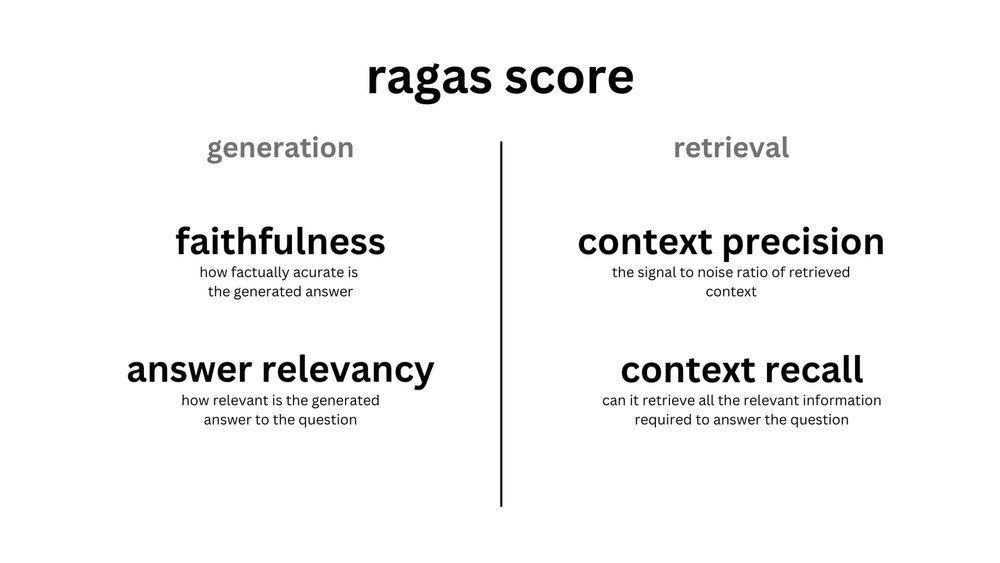


In [14]:
from tqdm import tqdm
# Take a sample of 25 and get responses as "answer"
sample_test_df = golden_df.sample(25, random_state=42).reset_index(drop=True)

output = []

def process_question(row):
    """Processes a single question and returns the required output format."""
    temp_info = {'question': row['input']}
    temp_info['ground_truth'] = row['expected_output']
    nodes = retriever.retrieve(row['input'])
    context_str = "\n\n".join([n.node.get_content() for n in nodes])
    messages_chat = [
                {"content": qa_template.format(context_str=context_str, query_str=row['input']), "role": "user"}
            ]

    response = completion(model='gemini/gemini-2.5-flash', messages=messages_chat, temperature=1, stream=False)
    response_text = response.choices[0].message.content
    temp_info['answer'] = response_text # Convert response object to string
    temp_info['contexts'] = [node.node.text for node in nodes]
    return temp_info


for _, row in tqdm(sample_test_df.iterrows(), total=sample_test_df.shape[0]):
    output.append(process_question(row))


sample_test_df = pd.DataFrame(output)

100%|██████████| 25/25 [02:43<00:00,  6.55s/it]

time: 2min 43s (started: 2025-11-24 19:08:33 +00:00)


In [15]:
sample_test_df.sample(5)

,question,ground_truth,answer,contexts
15,Outline the necessary sequential actions for e...,"To effectively prepare surfaces for painting, ...",Effective surface preparation is crucial for o...,[Forward) \nResult: > 100 in-lb\nBlock Resis...
5,Imagine a scenario where a new building materi...,The Urethane Alkyd Semi-Gloss Enamel is design...,"Based on the provided context, there is no men...","[Set nails and fill holes, scratches, and goug..."
19,What are the specific dry times for paint at 7...,"At 77°F and 50% relative humidity, the specifi...","I apologize, but the provided context informat...","[WARNING! If you scrape, sand or remove old pa..."
13,How does the cleanup process for a paint spill...,The cleanup process for a paint spill involves...,"Based on the provided context, there is **insu...",[CAUSES EYE AND SKIN IRRITATION. \nMAY CAUSE R...
2,Outline emergency protocols for handling hazar...,"In domestic settings with children, follow the...","Based on the provided context information, her...",[MAY CAUSE DROWSINESS \nOR DIZZINESS. COMBUSTI...


time: 43.7 ms (started: 2025-11-24 19:11:16 +00:00)


In [16]:
sample_test_df.head(1)

,question,ground_truth,answer,contexts
0,Envision a scenario where surfaces are imprope...,Improper surface preparation before painting c...,If surfaces are improperly prepped before pain...,[875 \n2 coats BEHR PRO Pre-Catalyzed Waterbor...


time: 29.7 ms (started: 2025-11-24 19:11:16 +00:00)


In [18]:
result = evaluate(
    Dataset.from_pandas(sample_test_df[['question', 'ground_truth', 'answer', 'contexts']]),
    metrics=[
        context_precision,
        faithfulness,
        answer_relevancy,
        context_recall,
    ]
)

result

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[1]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[2]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[3]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[4]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[5]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[6]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ragas.executor:Exception raised in Job[7]: AttributeError('InstructorLLM' object has no attribute 'agenerate_prompt')
ERROR:ra

{'context_precision': nan, 'faithfulness': nan, 'answer_relevancy': nan, 'context_recall': nan}

time: 1.26 s (started: 2025-11-24 19:17:24 +00:00)


Given the small subset of testing examples, we can start to measure how well our system is doing. That being said, there are many ways for us to further evaluate the system as well as explore how to improve. We will explore this more during the next lab.

When I ran my sample, I saw the following metrics:

```
{'context_precision': 0.6867, 'faithfulness': 0.7028, 'answer_relevancy': 0.3917, 'context_recall': 0.7307}

```



time: 41.3 s (started: 2025-11-24 19:17:24 +00:00)
